# Six-frequency FBTDCA training — 2-second epochs

Train and validate a participant-specific 8/9/10/13/14/15 Hz model from at least two complete collection sessions. Each stimulus lasts 2.25 seconds; the first 0.25 seconds are discarded and the model receives exactly 2.0 seconds (500 samples at 250 Hz).

In [1]:
from pathlib import Path
import os
import matplotlib.pyplot as plt
import numpy as np
from ssvep_bci.training import (
    discover_collection_sessions, load_fbtdca_dataset,
    save_fbtdca_model, train_fbtdca,
)

def find_repo_root():
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "ssvep-bci" / "pyproject.toml").is_file():
            return candidate
        if (candidate / "src" / "ssvep_bci").is_dir():
            return candidate.parent
    raise FileNotFoundError("Could not locate the BCI repository root")

REPO_ROOT = find_repo_root()
EXPERIMENT_ID = "six-frequency-fbtdca-collection"
PARTICIPANT_ID = os.getenv("SSVEP_PARTICIPANT_ID", "mike_a")
SESSION_ROOT = Path(os.getenv("SSVEP_SESSION_ROOT", str(REPO_ROOT / "ssvep-bci/sessions")))
SESSION_PATHS_VALUE = os.getenv("SSVEP_SESSION_PATHS")
WINDOW_ONSET_OFFSET_SECONDS = 0.25
WINDOW_LENGTH_SECONDS = 2.0
MODEL_PATH = Path(os.getenv("SSVEP_MODEL_PATH", str(REPO_ROOT / "ssvep-bci/models" / PARTICIPANT_ID / "six_frequency_fbtdca_2s.joblib")))

## Discover sessions and extract timestamp-aligned 2-second epochs

Set `SSVEP_SESSION_PATHS` to a path-separated list when the session directory also contains sessions from another six-frequency timing profile. Otherwise, complete collection sessions are discovered under `SSVEP_SESSION_ROOT`.

In [2]:
if SESSION_PATHS_VALUE:
    session_paths = tuple(
        Path(value).expanduser().resolve()
        for value in SESSION_PATHS_VALUE.split(os.pathsep)
        if value
    )
else:
    session_paths = discover_collection_sessions(
        SESSION_ROOT, PARTICIPANT_ID, experiment_id=EXPERIMENT_ID
    )
missing_paths = [path for path in session_paths if not path.is_dir()]
if missing_paths:
    raise FileNotFoundError(f"Missing configured session folders: {missing_paths}")
if len(session_paths) < 2:
    raise ValueError("At least two complete collection sessions are required")
dataset = load_fbtdca_dataset(
    session_paths, PARTICIPANT_ID, experiment_id=EXPERIMENT_ID,
    window_onset_offset_seconds=WINDOW_ONSET_OFFSET_SECONDS,
    window_length_seconds=WINDOW_LENGTH_SECONDS,
)
class_count = len(dataset.candidate_frequencies_hz)
print("Sessions:", len(dataset.session_paths))
print("EEG shape (trials, channels, samples):", dataset.eeg.shape)
print("Window:", dataset.window_onset_offset_seconds, "to",
      dataset.window_onset_offset_seconds + dataset.window_length_seconds, "seconds")
print("Frequencies:", dataset.candidate_frequencies_hz)
print("Excluded incomplete trials:", len(dataset.excluded_trials))
print("Trials per class:", np.bincount(dataset.labels, minlength=class_count))

Sessions: 2
EEG shape (trials, channels, samples): (143, 8, 500)
Window: 0.25 to 2.25 seconds
Frequencies: (8.0, 9.0, 10.0, 13.0, 14.0, 15.0)
Excluded incomplete trials: 1
Trials per class: [23 24 24 24 24 24]


## Leave-one-session-out validation and final fit

In [3]:
estimator, validation = train_fbtdca(dataset)
for fold in validation["folds"]:
    print(f"{fold['held_out_session_id']}: balanced accuracy {fold['balanced_accuracy']:.3f}")
print(f"Overall accuracy: {validation['accuracy']:.3f}")
print(f"Overall balanced accuracy: {validation['balanced_accuracy']:.3f}")

3ba18254-3978-4148-bc18-13ee7e6f520d: balanced accuracy 0.347
da77a451-8f28-45ad-94e1-ffbecc48739c: balanced accuracy 0.419
Overall accuracy: 0.385
Overall balanced accuracy: 0.384


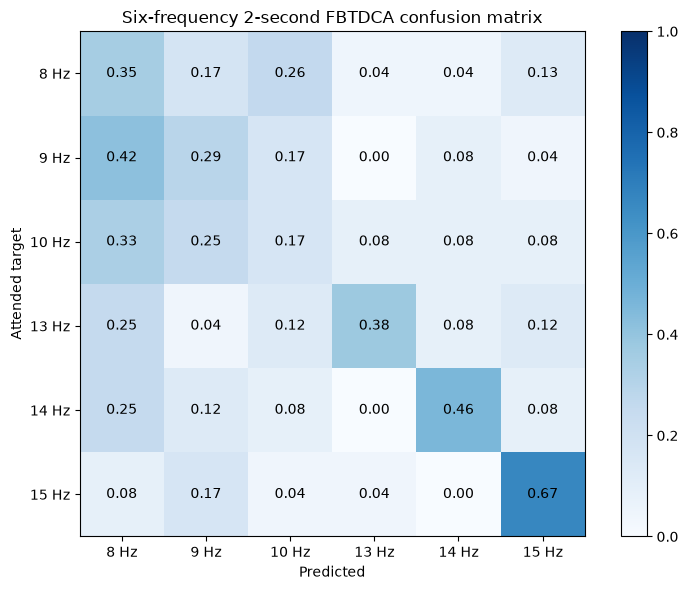

In [4]:
matrix = np.asarray(validation["normalized_confusion_matrix"])
fig, ax = plt.subplots(figsize=(8, 6))
image = ax.imshow(matrix, cmap="Blues", vmin=0, vmax=1)
frequency_labels = [f"{value:g} Hz" for value in dataset.candidate_frequencies_hz]
indexes = range(class_count)
ax.set(xticks=indexes, yticks=indexes, xticklabels=frequency_labels,
       yticklabels=frequency_labels, xlabel="Predicted",
       ylabel="Attended target",
       title="Six-frequency 2-second FBTDCA confusion matrix")
for row in indexes:
    for column in indexes:
        ax.text(column, row, f"{matrix[row, column]:.2f}", ha="center", va="center")
fig.colorbar(image, ax=ax)
fig.tight_layout()
plt.show()

## Save the 2-second estimator and reproducibility metadata

In [5]:
saved_model, saved_summary = save_fbtdca_model(
    dataset, estimator, validation, MODEL_PATH
)
print("Saved model:", saved_model)
print("Saved summary:", saved_summary)

Saved model: C:\Users\MykhailoAntropov\IdeaProjects\turiba\BCI\ssvep-bci\models\mike_a\six_frequency_fbtdca_2s.joblib
Saved summary: C:\Users\MykhailoAntropov\IdeaProjects\turiba\BCI\ssvep-bci\models\mike_a\six_frequency_fbtdca_2s_summary.json
